In [18]:
import pandas as pd
import numpy as np
from IPython.display import display, Markdown



### Raw data (preview)

,State,County,Year,Days with AQI,Good Days,Moderate Days,Unhealthy for Sensitive Groups Days,Unhealthy Days,Very Unhealthy Days,Hazardous Days,Max AQI,90th Percentile AQI,Median AQI,Days CO,Days NO2,Days Ozone,Days SO2,Days PM2.5,Days PM10
0,Alabama,Baldwin,2012,284,226,56,2,0,0,0,112,61,38,0,0,210,0,74,0
1,Alabama,Clay,2012,121,99,22,0,0,0,0,72,56,35,0,0,0,0,121,0
2,Alabama,Colbert,2012,283,222,55,6,0,0,0,136,62,40,0,0,209,0,74,0
3,Alabama,DeKalb,2012,361,282,74,5,0,0,0,115,64,40,0,0,320,0,41,0
4,Alabama,Elmore,2012,245,212,33,0,0,0,0,100,54,40,0,0,245,0,0,0
5,Alabama,Etowah,2012,277,229,48,0,0,0,0,87,55,40,0,0,191,0,86,0
6,Alabama,Houston,2012,284,238,46,0,0,0,0,97,58,38,0,0,211,0,73,0
7,Alabama,Jefferson,2012,366,148,198,16,4,0,0,172,87,53,0,0,140,7,216,3


Shape: (1071, 19)


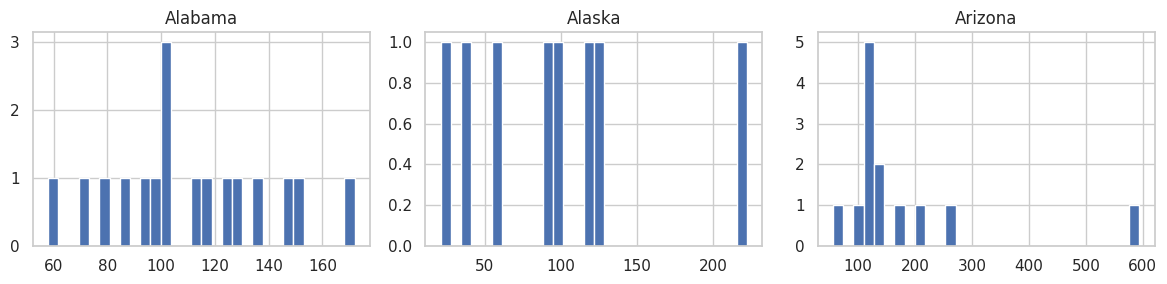

In [20]:


# ---------- Load ----------
FILE = "Air_county.xlsx"
df = pd.read_excel(FILE)
show("Raw data (preview)", df)
print("Shape:", df.shape)


fig, axes = plt.subplots(ncols=3, figsize=(12,3))  # adjust number of cols
for ax, (state, sub) in zip(axes, df.groupby("State")):
    ax.hist(sub["Max AQI"].dropna(), bins=30)
    ax.set_title(state)
plt.tight_layout()


# Make DataFrames easier to read
pd.set_option("display.max_rows", 50)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

def show(title, frame, rows=8):
    display(Markdown(f"### {title}"))
    display(frame.head(rows))


In [21]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in df.columns if c not in num_cols]
print("Numeric columns (#):", len(num_cols))
print(num_cols)
print("Categorical/other:", cat_cols)


Numeric columns (#): 17
['Year', 'Days with AQI', 'Good Days', 'Moderate Days', 'Unhealthy for Sensitive Groups Days', 'Unhealthy Days', 'Very Unhealthy Days', 'Hazardous Days', 'Max AQI', '90th Percentile AQI', 'Median AQI', 'Days CO', 'Days NO2', 'Days Ozone', 'Days SO2', 'Days PM2.5', 'Days PM10']
Categorical/other: ['State', 'County']


In [22]:
def minmax(col):
    cmin, cmax = col.min(), col.max()
    if cmax == cmin:
        return pd.Series(0, index=col.index)
    return (col - cmin) / (cmax - cmin)

def zscore(col):
    sd = col.std(ddof=0)
    if sd == 0:
        return pd.Series(0, index=col.index)
    return (col - col.mean()) / sd

minmax_df = df[num_cols].apply(minmax)
zscore_df = df[num_cols].apply(zscore)

show("Min–Max normalized (preview)", minmax_df)
show("Z-score standardized (preview)", zscore_df)


### Min–Max normalized (preview)

,Year,Days with AQI,Good Days,Moderate Days,Unhealthy for Sensitive Groups Days,Unhealthy Days,Very Unhealthy Days,Hazardous Days,Max AQI,90th Percentile AQI,Median AQI,Days CO,Days NO2,Days Ozone,Days SO2,Days PM2.5,Days PM10
0,0,0.769014,0.619178,0.177778,0.014925,0.0000,0.0,0.0,0.023655,0.283505,0.222222,0.0,0.0,0.573770,0.000000,0.202186,0.000000
1,0,0.309859,0.271233,0.069841,0.000000,0.0000,0.0,0.0,0.013257,0.257732,0.204678,0.0,0.0,0.000000,0.000000,0.330601,0.000000
2,0,0.766197,0.608219,0.174603,0.044776,0.0000,0.0,0.0,0.029893,0.288660,0.233918,0.0,0.0,0.571038,0.000000,0.202186,0.000000
3,0,0.985915,0.772603,0.234921,0.037313,0.0000,0.0,0.0,0.024435,0.298969,0.233918,0.0,0.0,0.874317,0.000000,0.112022,0.000000
4,0,0.659155,0.580822,0.104762,0.000000,0.0000,0.0,0.0,0.020535,0.247423,0.233918,0.0,0.0,0.669399,0.000000,0.000000,0.000000
5,0,0.749296,0.627397,0.152381,0.000000,0.0000,0.0,0.0,0.017156,0.252577,0.233918,0.0,0.0,0.521858,0.000000,0.234973,0.000000
6,0,0.769014,0.652055,0.146032,0.000000,0.0000,0.0,0.0,0.019756,0.268041,0.222222,0.0,0.0,0.576503,0.000000,0.199454,0.000000
7,0,1.000000,0.405479,0.628571,0.119403,0.0181,0.0,0.0,0.039251,0.417526,0.309942,0.0,0.0,0.382514,0.019126,0.590164,0.008197


### Z-score standardized (preview)

,Year,Days with AQI,Good Days,Moderate Days,Unhealthy for Sensitive Groups Days,Unhealthy Days,Very Unhealthy Days,Hazardous Days,Max AQI,90th Percentile AQI,Median AQI,Days CO,Days NO2,Days Ozone,Days SO2,Days PM2.5,Days PM10
0,0,-0.278880,0.014866,-0.339481,-0.499562,-0.191580,-0.180833,-0.083454,-0.171800,-0.301242,-0.022252,-0.077882,-0.232549,0.355820,-0.246665,-0.298820,-0.263050
1,0,-2.097518,-1.550150,-0.979992,-0.652493,-0.191580,-0.180833,-0.083454,-0.396586,-0.529153,-0.255136,-0.077882,-0.232549,-1.401595,-0.246665,0.133612,-0.263050
2,0,-0.290037,-0.034426,-0.358319,-0.193699,-0.191580,-0.180833,-0.083454,-0.036929,-0.255660,0.133004,-0.077882,-0.232549,0.347451,-0.246665,-0.298820,-0.263050
3,0,0.580231,0.704952,-0.000387,-0.270165,-0.191580,-0.180833,-0.083454,-0.154941,-0.164496,0.133004,-0.077882,-0.232549,1.276370,-0.246665,-0.602442,-0.263050
4,0,-0.714014,-0.157656,-0.772768,-0.652493,-0.191580,-0.180833,-0.083454,-0.239236,-0.620318,0.133004,-0.077882,-0.232549,0.648722,-0.246665,-0.979670,-0.263050
5,0,-0.356981,0.051835,-0.490189,-0.652493,-0.191580,-0.180833,-0.083454,-0.312291,-0.574736,0.133004,-0.077882,-0.232549,0.196815,-0.246665,-0.188412,-0.263050
6,0,-0.278880,0.162741,-0.527866,-0.652493,-0.191580,-0.180833,-0.083454,-0.256095,-0.437989,-0.022252,-0.077882,-0.232549,0.364188,-0.246665,-0.308021,-0.263050
7,0,0.636017,-0.946325,2.335594,0.570958,0.317557,-0.180833,-0.083454,0.165378,0.883894,1.142167,-0.077882,-0.232549,-0.229985,-0.126435,1.007676,-0.207704


In [23]:
# ---------- 3) One-hot encode State ----------
if "State" in df.columns:
    state_dummies = pd.get_dummies(df["State"], prefix="State", drop_first=False)
    show("One-hot: State (preview)", state_dummies)
    print("One-hot State columns (#):", state_dummies.shape[1])
else:
    state_dummies = pd.DataFrame(index=df.index)
    print("No 'State' column found.")



### One-hot: State (preview)

,State_Alabama,State_Alaska,State_Arizona,State_Arkansas,State_California,State_Colorado,State_Connecticut,State_Country Of Mexico,State_Delaware,State_District Of Columbia,State_Florida,State_Georgia,State_Hawaii,State_Idaho,State_Illinois,State_Indiana,State_Iowa,State_Kansas,State_Kentucky,State_Louisiana,State_Maine,State_Maryland,State_Massachusetts,State_Michigan,State_Minnesota,...,State_Nevada,State_New Hampshire,State_New Jersey,State_New Mexico,State_New York,State_North Carolina,State_North Dakota,State_Ohio,State_Oklahoma,State_Oregon,State_Pennsylvania,State_Puerto Rico,State_Rhode Island,State_South Carolina,State_South Dakota,State_Tennessee,State_Texas,State_Utah,State_Vermont,State_Virgin Islands,State_Virginia,State_Washington,State_West Virginia,State_Wisconsin,State_Wyoming
0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
5,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
6,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
7,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


One-hot State columns (#): 54


In [24]:
# ---------- 4) Discretize / Bin Max AQI into 4 equal-width bins ----------
if "County" in df.columns:
    county_cat = df["County"].astype("category")
    county_codes = county_cat.cat.codes
    label_df = pd.DataFrame({"County": df["County"], "County_code": county_codes})
    show("Label-encoded County (preview)", label_df)

    # Show the first 12 category→code mappings as a table
    mapping = (
        pd.DataFrame({"County_category": county_cat.cat.categories})
        .reset_index().rename(columns={"index": "County_code"})
        .head(12)
    )
    show("County mapping (first 12)", mapping)
else:
    print("No 'County' column found.")


### Label-encoded County (preview)

,County,County_code
0,Baldwin,43
1,Clay,161
2,Colbert,173
3,DeKalb,208
4,Elmore,248
5,Etowah,252
6,Houston,340
7,Jefferson,360


### County mapping (first 12)

,County_code,County_category
0,0,Abbeville
1,1,Ada
2,2,Adair
3,3,Adams
4,4,Adjuntas
5,5,Aiken
6,6,Alachua
7,7,Alamance


In [26]:

labels = ["Low", "Moderate", "High", "Very High"]
if "Max AQI" in df.columns:
    max_aqi_binned = pd.cut(df["Max AQI"], bins=4, labels=labels, include_lowest=True)
    bin_counts = (max_aqi_binned.value_counts()
                  .reindex(labels)
                  .rename_axis("Max_AQI_bin")
                  .reset_index(name="count"))
    show("Max AQI — 4 equal-width bins (counts)", bin_counts)
else:
    print("No 'Max AQI' column found.")


### Max AQI — 4 equal-width bins (counts)

,Max_AQI_bin,count
0,Low,1067
1,Moderate,2
2,High,0
3,Very High,2


In [27]:
stats_rows = []
for col in ["Max AQI", "Median AQI"]:
    if col in df.columns:
        stats_rows.append({"metric": f"Skew({col})", "value": df[col].skew()})
skew_tbl = pd.DataFrame(stats_rows)
show("Skewness (selected columns)", skew_tbl)

if "Max AQI" in df.columns:
    df["Max_AQI_log1p"] = np.log1p(df["Max AQI"])
    before_after = pd.DataFrame({
        "metric": ["Skew Max AQI", "Skew Max_AQI_log1p"],
        "value": [df["Max AQI"].skew(), df["Max_AQI_log1p"].skew()]
    })
    show("Max AQI — skew before/after log1p", before_after)

    bb = df[["Max AQI", "Max_AQI_log1p"]].describe().round(2)
    show("Max AQI — describe before/after", bb)


### Skewness (selected columns)

,metric,value
0,Skew(Max AQI),17.546819
1,Skew(Median AQI),0.678350


### Max AQI — skew before/after log1p

,metric,value
0,Skew Max AQI,17.546819
1,Skew Max_AQI_log1p,0.514110


### Max AQI — describe before/after

,Max AQI,Max_AQI_log1p
count,1071.00,1071.00
mean,142.57,4.83
std,178.03,0.45
min,21.00,3.09
25%,97.00,4.58
50%,133.00,4.90
75%,161.00,5.09
max,3868.00,8.26


In [29]:
bad_cols = [
    "Unhealthy for Sensitive Groups Days",
    "Unhealthy Days",
    "Very Unhealthy Days",
    "Hazardous Days",
]
present = [c for c in bad_cols if c in df.columns]
if present:
    df["Bad_Air_Days"] = df[present].sum(axis=1)
    show("Engineered: Bad_Air_Days (preview)", df[["Bad_Air_Days"]])
    print("Rows with Bad_Air_Days > 10:", int((df["Bad_Air_Days"] > 10).sum()))
else:
    print("Not all inputs for Bad_Air_Days found; skipping.")


### Engineered: Bad_Air_Days (preview)

,Bad_Air_Days
0,2
1,0
2,6
3,5
4,0
5,0
6,0
7,20


Rows with Bad_Air_Days > 10: 348


from matplotlib import pyplot as plt
_df_84['Bad_Air_Days'].plot(kind='hist', bins=20, title='Bad_Air_Days')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_85['Bad_Air_Days'].plot(kind='line', figsize=(8, 4), title='Bad_Air_Days')
plt.gca().spines[['top', 'right']].set_visible(False)

In [31]:
corr = df.select_dtypes(include=[np.number]).corr().round(2)
show("Correlation matrix (numeric, rounded)", corr)

# If you want just the strongest pairs as a table:
pairs = []
num_cols_now = corr.columns.tolist()
for i, a in enumerate(num_cols_now):
    for b in num_cols_now[i+1:]:
        r = corr.loc[a, b]
        if abs(r) >= 0.70:
            pairs.append((a, b, r))
high_corr_tbl = pd.DataFrame(pairs, columns=["col_a", "col_b", "r"]).sort_values(by="r", key=lambda s: s.abs(), ascending=False)
show("High correlation pairs (|r| ≥ 0.70)", high_corr_tbl)


### Correlation matrix (numeric, rounded)

,Year,Days with AQI,Good Days,Moderate Days,Unhealthy for Sensitive Groups Days,Unhealthy Days,Very Unhealthy Days,Hazardous Days,Max AQI,90th Percentile AQI,Median AQI,Days CO,Days NO2,Days Ozone,Days SO2,Days PM2.5,Days PM10,Max_AQI_log1p,Bad_Air_Days
Year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Days with AQI,NaN,1.00,0.73,0.51,0.21,0.08,0.08,0.05,0.13,0.21,0.25,0.01,0.12,0.36,0.13,0.30,0.05,0.41,0.18
Good Days,NaN,0.73,1.00,-0.19,-0.32,-0.19,-0.11,-0.01,-0.01,-0.36,-0.34,0.05,0.12,0.27,0.20,0.11,0.13,0.01,-0.30
Moderate Days,NaN,0.51,-0.19,1.00,0.50,0.12,0.15,0.04,0.18,0.65,0.71,-0.05,0.02,0.16,-0.13,0.36,-0.10,0.52,0.40
Unhealthy for Sensitive Groups Days,NaN,0.21,-0.32,0.50,1.00,0.58,0.33,0.10,0.18,0.79,0.63,-0.03,0.02,0.19,0.08,-0.05,-0.06,0.49,0.94
Unhealthy Days,NaN,0.08,-0.19,0.12,0.58,1.00,0.41,0.17,0.10,0.44,0.47,-0.01,-0.00,-0.02,0.16,0.02,-0.02,0.23,0.82
Very Unhealthy Days,NaN,0.08,-0.11,0.15,0.33,0.41,1.00,0.17,0.21,0.32,0.22,-0.00,0.01,-0.02,0.02,0.07,0.02,0.30,0.42
Hazardous Days,NaN,0.05,-0.01,0.04,0.10,0.17,0.17,1.00,0.73,0.09,0.06,-0.00,0.05,-0.03,0.01,-0.03,0.18,0.41,0.16


### High correlation pairs (|r| ≥ 0.70)

,col_a,col_b,r
3,Unhealthy for Sensitive Groups Days,Bad_Air_Days,0.94
4,Unhealthy Days,Bad_Air_Days,0.82
6,90th Percentile AQI,Median AQI,0.82
2,Unhealthy for Sensitive Groups Days,90th Percentile AQI,0.79
7,90th Percentile AQI,Bad_Air_Days,0.74
0,Days with AQI,Good Days,0.73
5,Hazardous Days,Max AQI,0.73
1,Moderate Days,Median AQI,0.71


from matplotlib import pyplot as plt
_df_86['r'].plot(kind='hist', bins=20, title='r')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['col_b'].value_counts()
    for x_label, grp in _df_90.groupby('col_a')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('col_a')
_ = plt.ylabel('col_b')

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_91['col_a'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_91, x='r', y='col_a', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_92['col_b'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_92, x='r', y='col_b', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)